In [13]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [14]:
pretrained_model = tf.keras.applications.VGG19(
  include_top=False,
  input_shape=(180,180,3),
  pooling='avg',
  classes=5,
  weights='imagenet'
)

In [15]:
for layer in pretrained_model.layers:
  print(layer.name)

input_layer
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_conv4
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_conv4
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_conv4
block5_pool
global_average_pooling2d


In [16]:
pretrained_model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
head = pretrained_model.output
head = tf.keras.layers.Flatten()(head)
head = tf.keras.layers.Dense(units=512,activation='relu')(head)
head = tf.keras.layers.Dropout(0.1)(head) #10%
head = tf.keras.layers.Dense(units=128,activation='relu')(head)
head = tf.keras.layers.Dropout(0.1)(head)
head = tf.keras.layers.Dense(units=64,activation='relu')(head)
head = tf.keras.layers.Dropout(0.1)(head)
head = tf.keras.layers.Dense(units=32,activation='relu')(head)
head = tf.keras.layers.Dropout(0.1)(head)
head = tf.keras.layers.Dense(units=5,activation='softmax')(head)
model = tf.keras.Model(inputs=pretrained_model.input,outputs=head)

In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,363,205 (77.68 MB)

 Trainable params: 20,363,205 (77.68 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
for layer in pretrained_model.layers:
  layer.trainable = False
  print(layer.name, layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_conv4 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_conv4 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_conv4 False
block5_pool False
global_average_pooling2d False


In [20]:
model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
  loss='categorical_crossentropy',
  metrics=['accuracy']
)

In [21]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
  './data/Vegetable Images/train',
  labels='inferred',
  image_size=(180, 180),
  label_mode='categorical',
  interpolation='bilinear',
  validation_split=0.9,
  subset="training",
  seed=1234
)

Found 5000 files belonging to 5 classes.
Using 500 files for training.


In [22]:
# val_data
validate_data = tf.keras.preprocessing.image_dataset_from_directory(
  './data/Vegetable Images/train',
  labels='inferred',
  image_size=(180, 180),
  label_mode='categorical',
  interpolation='bilinear',
  validation_split=0.020,
  subset="validation",
  seed=1234,
  color_mode='rgb'
)

Found 5000 files belonging to 5 classes.
Using 100 files for validation.


In [23]:
print(train_data.class_names)

['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli']


(32, 180, 180, 3) (32, 5)


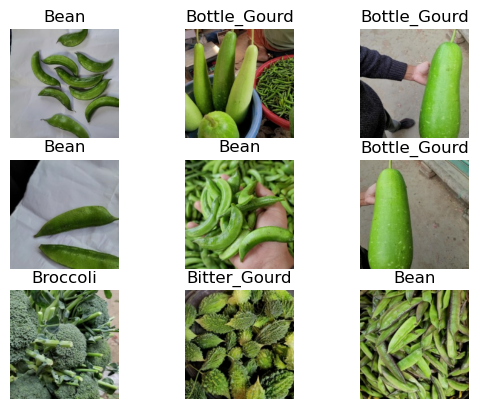

In [24]:
train_class_names = train_data.class_names

for images, labels in train_data.take(1):
  for idx in range(9):
    ax = plt.subplot(3, 3, idx + 1)
    plt.imshow(images[idx].numpy().astype("uint8"))
    plt.axis("off")
    plt.title(f"{
      train_class_names[np.argmax(labels[idx])]
    }")


    # print(labels[idx])
  print(images.shape, labels.shape)

(32, 180, 180, 3) (32, 5)


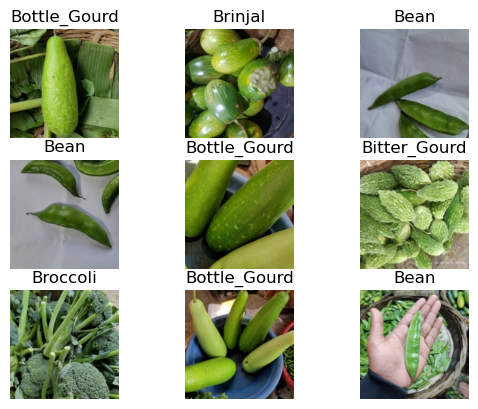

In [25]:
validate_class_names = validate_data.class_names

for images, labels in validate_data.take(1):
  for idx in range(9):
    ax = plt.subplot(3, 3, idx + 1)
    plt.imshow(images[idx].numpy().astype("uint8"))
    plt.axis("off")
    plt.title(f"{
      validate_class_names[np.argmax(labels[idx])]
    }")


    # print(labels[idx])
  print(images.shape, labels.shape)

In [26]:
history1 = model.fit(train_data, epochs=5, validation_data=validate_data)
history2 = model.fit(train_data, epochs=5, validation_data=validate_data)
history3 = model.fit(train_data, epochs=5, validation_data=validate_data)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.6940 - loss: 0.9290 - val_accuracy: 0.9800 - val_loss: 0.1078
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.9080 - loss: 0.2337 - val_accuracy: 0.9800 - val_loss: 0.0707
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.9620 - loss: 0.1380 - val_accuracy: 0.9600 - val_loss: 0.0710
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.9740 - loss: 0.0763 - val_accuracy: 0.9700 - val_loss: 0.0906
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.9840 - loss: 0.0428 - val_accuracy: 0.9900 - val_loss: 0.0247
Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.9920 - loss: 0.0228 - val_accuracy: 0.9800 - val_loss: 0.0351
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.9940 - loss: 0.0201 - val_accuracy: 1.0000 - val_loss: 0.0104
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.9960 - loss: 0.0192 - val_accuracy: 0.9900 - val_loss: 0.0155


In [32]:
model.save("Best.keras")

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [34]:
class_label = ['cat', 'dog', 'person']
np.random.seed(1234)

y_label = np.random.choice(class_label, size=100, p=[0.4, 0.3, 0.3])
y_predict = np.random.choice(class_label, size=100, p=[0.35, 0.3, 0.35])


In [35]:
cm = confusion_matrix(y_label, y_predict, labels=class_label)

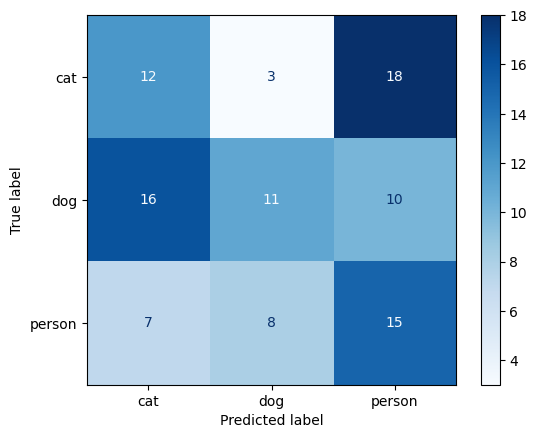

In [36]:
disp = ConfusionMatrixDisplay(
  confusion_matrix=cm, 
  display_labels=class_label,
)
disp.plot(cmap=plt.cm.Blues)
plt.show()
  

In [37]:
# ฟังก์ชันช่วยดึง label และ predict จาก tf.data.Dataset
def get_true_pred(model, dataset):
    y_true = []
    y_pred = []
    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


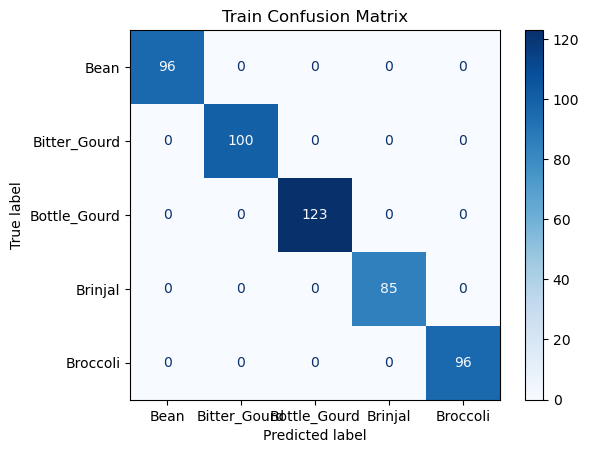

In [38]:
# Train confusion matrix
y_true_train, y_pred_train = get_true_pred(model, train_data)
cm_train = confusion_matrix(y_true_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=train_data.class_names)
disp_train.plot(cmap=plt.cm.Blues)
plt.title("Train Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step


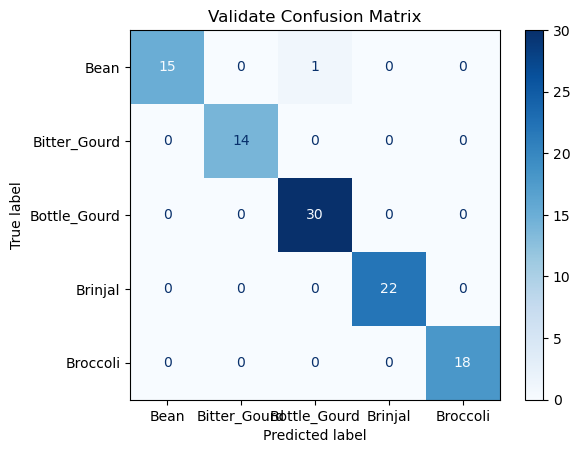

In [39]:
# Validate confusion matrix
y_true_val, y_pred_val = get_true_pred(model, validate_data)
cm_val = confusion_matrix(y_true_val, y_pred_val)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=validate_data.class_names)
disp_val.plot(cmap=plt.cm.Blues)
plt.title("Validate Confusion Matrix")
plt.show()